# DMS Dataset Overview Dashboard

Notebook tổng quan toàn bộ dữ liệu đang có trong dự án:

- Face landmarks: `landmarks.csv`
- Smoking landmarks: `smoking_landmarks.csv`, `smoking_landmarks_binary.csv`
- Hand landmarks: `hand_dataset.csv`
- Phone runtime/data: `phone_data.csv`
- Image/label counts trong `driver_training/dataset` nếu có

Mục tiêu là có nhiều biểu đồ nhanh để đưa vào báo cáo hoặc soi chất lượng data.

In [1]:
from pathlib import Path
from collections import Counter
import csv

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
NOTEBOOK_DIR = Path.cwd()
BACKEND_CANDIDATES = [NOTEBOOK_DIR / ".." / "..", Path("../.."), Path("DiQuaMuaHaa/backend")]
BACKEND_DIR = next((p.resolve() for p in BACKEND_CANDIDATES if (p / "driver_training").exists()), None)
if BACKEND_DIR is None:
    raise FileNotFoundError("Không tìm thấy backend")

OUT_DIR = (NOTEBOOK_DIR / "outputs" / "overview").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "face_landmarks": BACKEND_DIR / "driver_training" / "collect" / "data" / "landmarks.csv",
    "smoking_only": BACKEND_DIR / "driver_training" / "collect" / "data" / "smoking_landmarks.csv",
    "smoking_binary": BACKEND_DIR / "driver_training" / "collect" / "data" / "smoking_landmarks_binary.csv",
    "hand_landmarks": BACKEND_DIR / "driver_training" / "collect" / "hand_dataset.csv",
    "phone_csv": BACKEND_DIR / "phone_data.csv",
}
BACKEND_DIR, OUT_DIR

(WindowsPath('D:/deployweb/conghienmegrge/DiQuaMuaHaa/backend'),
 WindowsPath('D:/deployweb/conghienmegrge/DiQuaMuaHaa/backend/driver_training/analysis/outputs/overview'))

In [3]:
def inspect_csv(path, has_header=None):
    if not path.exists():
        return {"exists": False, "rows": 0, "classes": {}, "feature_lens": {}}
    classes = Counter()
    lens = Counter()
    rows = 0
    with path.open(newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        for i, row in enumerate(reader):
            if not row:
                continue
            if i == 0 and (has_header is True or row[0].lower() in ['label', 'phone']):
                continue
            rows += 1
            classes[row[0]] += 1
            lens[len(row) - 1] += 1
    return {"exists": True, "rows": rows, "classes": dict(classes), "feature_lens": dict(lens)}

summary = {name: inspect_csv(path) for name, path in paths.items()}
summary_df = pd.DataFrame([
    {"dataset": name, "exists": info["exists"], "rows": info["rows"], "feature_lens": info["feature_lens"], "path": str(paths[name])}
    for name, info in summary.items()
])
display(summary_df)

,dataset,exists,rows,feature_lens,path
0,face_landmarks,True,471,{1434: 471},D:\deployweb\conghienmegrge\DiQuaMuaHaa\backen...
1,smoking_only,True,593,{1434: 593},D:\deployweb\conghienmegrge\DiQuaMuaHaa\backen...
2,smoking_binary,True,1186,{1434: 1186},D:\deployweb\conghienmegrge\DiQuaMuaHaa\backen...
3,hand_landmarks,True,1212,{63: 1212},D:\deployweb\conghienmegrge\DiQuaMuaHaa\backen...
4,phone_csv,True,0,{},D:\deployweb\conghienmegrge\DiQuaMuaHaa\backen...


## 1. Tổng số dòng theo dataset

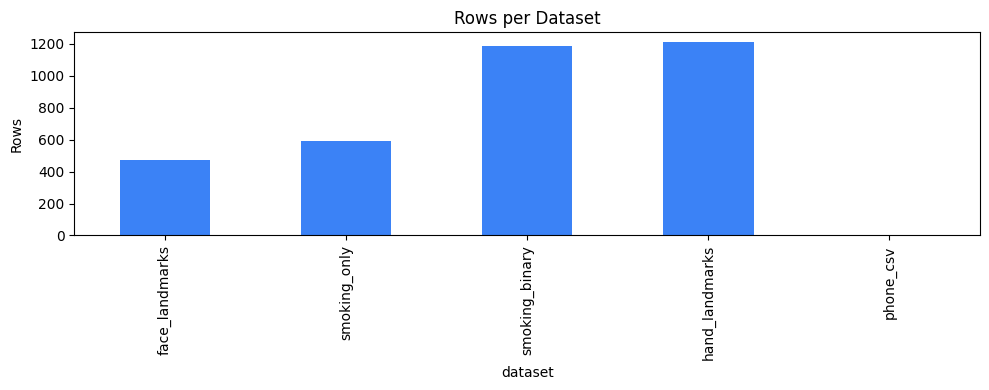

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
summary_df.set_index("dataset")["rows"].plot(kind="bar", ax=ax, color="#3b82f6")
ax.set_title("Rows per Dataset")
ax.set_ylabel("Rows")
plt.tight_layout()
fig.savefig(OUT_DIR / "01_rows_per_dataset.png", dpi=160)
plt.show()

## 2. Class distribution từng CSV

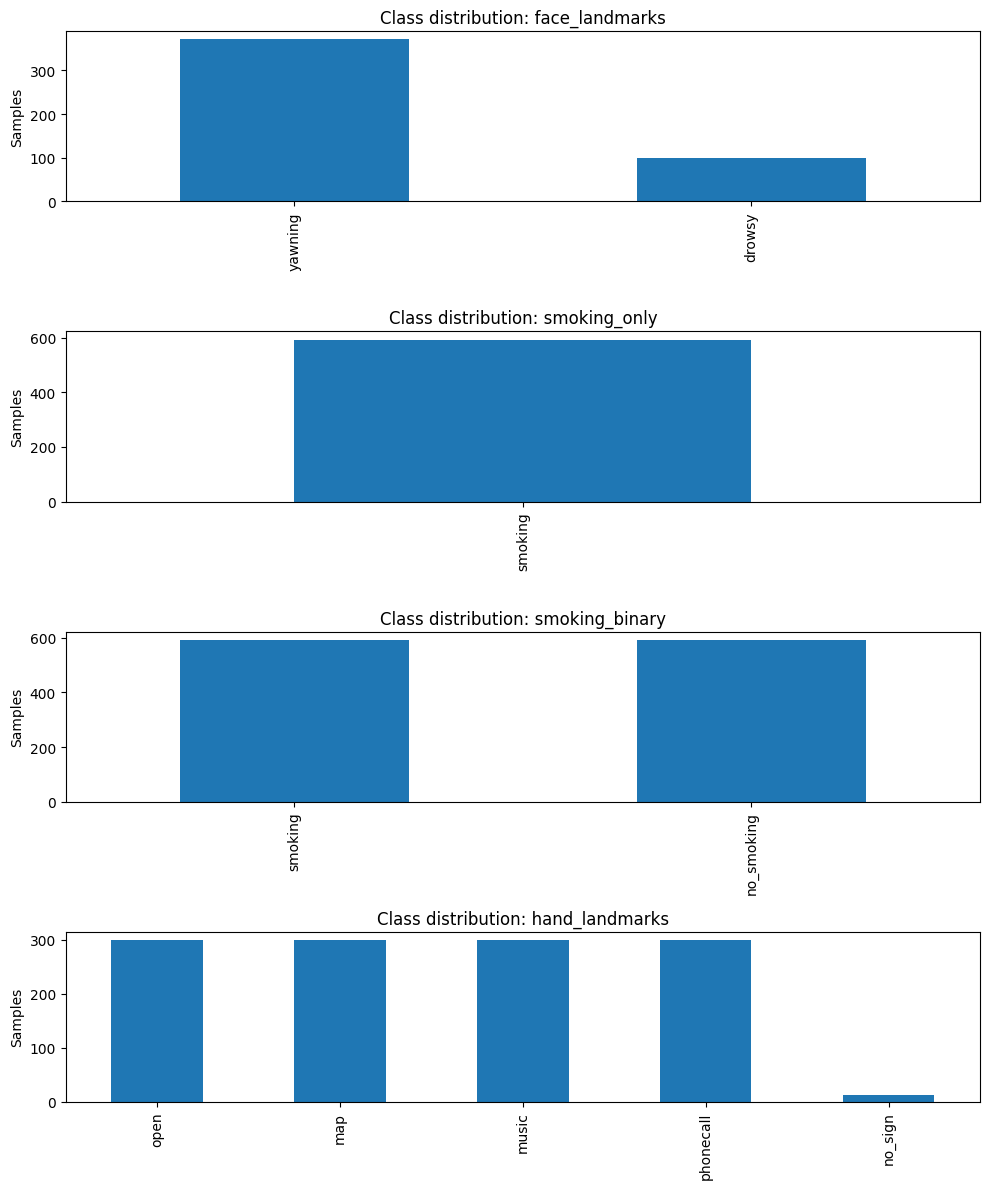

In [5]:
csv_items = [(name, info) for name, info in summary.items() if info["exists"] and info["classes"]]
fig, axes = plt.subplots(len(csv_items), 1, figsize=(10, max(3, 3 * len(csv_items))))
if len(csv_items) == 1:
    axes = [axes]
for ax, (name, info) in zip(axes, csv_items):
    pd.Series(info["classes"]).sort_values(ascending=False).plot(kind="bar", ax=ax)
    ax.set_title(f"Class distribution: {name}")
    ax.set_ylabel("Samples")
plt.tight_layout()
fig.savefig(OUT_DIR / "02_class_distributions_all_csv.png", dpi=160)
plt.show()

## 3. Feature length sanity check

Face/smoking thường là `1434 = 478*3`. Hand thường là `63 = 21*3`.

,dataset,feature_len,rows
0,face_landmarks,1434,471
1,smoking_only,1434,593
2,smoking_binary,1434,1186
3,hand_landmarks,63,1212


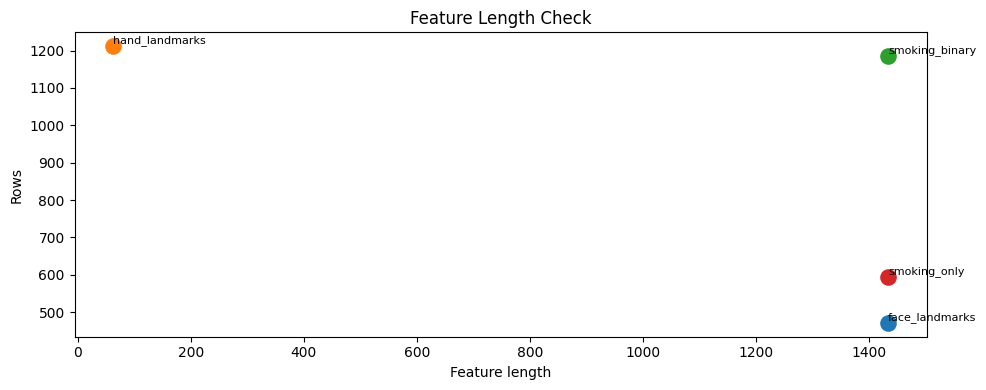

In [6]:
feature_rows = []
for name, info in summary.items():
    for flen, count in info["feature_lens"].items():
        feature_rows.append({"dataset": name, "feature_len": int(flen), "rows": count})
feature_df = pd.DataFrame(feature_rows)
display(feature_df)

if len(feature_df):
    fig, ax = plt.subplots(figsize=(10, 4))
    for dataset, group in feature_df.groupby("dataset"):
        ax.scatter(group["feature_len"], group["rows"], s=120, label=dataset)
        for _, r in group.iterrows():
            ax.text(r["feature_len"], r["rows"], dataset, fontsize=8, ha="left", va="bottom")
    ax.set_xlabel("Feature length")
    ax.set_ylabel("Rows")
    ax.set_title("Feature Length Check")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "03_feature_length_check.png", dpi=160)
    plt.show()

## 4. Image/label inventory trong driver_training/dataset

Dataset file counts: {'other': 4, 'yaml': 2, 'images': 44469, 'labels_txt': 44469}


,top_folder,kind,count
0,PHONE_DATASET_SOURCES.md,other,1
1,phone_yolo.yaml,yaml,1
4,yawning,images,44469
5,yawning,labels_txt,44469
2,yawning,other,3
3,yawning,yaml,1


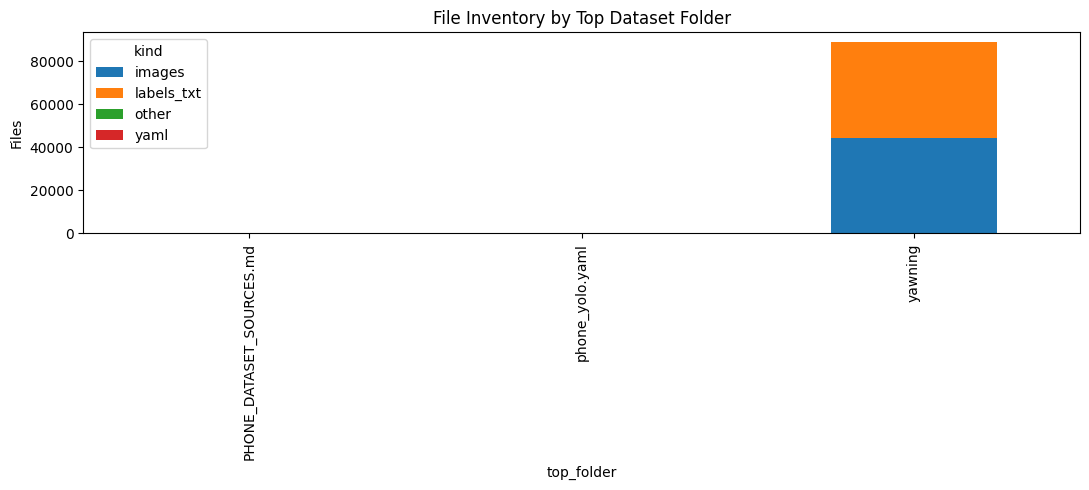

In [7]:
dataset_dir = BACKEND_DIR / "driver_training" / "dataset"
ext_groups = {
    "images": {".jpg", ".jpeg", ".png", ".bmp", ".webp"},
    "labels_txt": {".txt"},
    "json": {".json"},
    "yaml": {".yaml", ".yml"},
}
counts = Counter()
by_top = Counter()

if dataset_dir.exists():
    for p in dataset_dir.rglob("*"):
        if not p.is_file():
            continue
        kind = next((k for k, exts in ext_groups.items() if p.suffix.lower() in exts), "other")
        counts[kind] += 1
        rel = p.relative_to(dataset_dir)
        top = rel.parts[0] if rel.parts else "root"
        by_top[(top, kind)] += 1

print("Dataset file counts:", dict(counts))
inventory = pd.DataFrame([{"top_folder": k[0], "kind": k[1], "count": v} for k, v in by_top.items()])
display(inventory.sort_values(["top_folder", "kind"]))

if len(inventory):
    pivot = inventory.pivot_table(index="top_folder", columns="kind", values="count", fill_value=0)
    ax = pivot.plot(kind="bar", stacked=True, figsize=(11, 5))
    ax.set_title("File Inventory by Top Dataset Folder")
    ax.set_ylabel("Files")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "04_dataset_file_inventory.png", dpi=160)
    plt.show()
else:
    print("Không có file dataset image/label hoặc thư mục dataset trống.")

## 5. Checklist kết luận

- Face dataset hiện thiếu/đủ class nào?
- Hand `no_sign` có đủ mẫu chưa?
- Smoking binary có cân bằng không?
- Phone có dataset train/eval thật không, hay chỉ dùng COCO pretrained?
- Mỗi dataset có đúng feature length mong đợi không?